# Improving RAG with RAGAS

A RAG pipeline that works is not the same as one you can improve. To improve it you need questions with known answers and metrics that separate retrieval failures from generation failures. This notebook generates the questions from your corpus pages, scores the pipeline, changes one thing, and scores it again.

## Learn | Create | Grow

### Learn
Why a weak pipeline on purpose, how a synthetic test set is written by hand for one chunk and generated for the rest, and what four RAGAS metrics each measure.


### Create
A test set generated from your corpus and curated before you trust it, RAGAS scores on your pipeline, one retrieval change, and the scores again with an interval on the difference.



### Grow
Production teams keep the test set under version control and rerun it on every retrieval change. Tell your team your weakest metric and which way it moved.


**Estimated time:** 40 minutes
**Reads:** corpus
**Writes:** testset, ragas_scores

## Setup

This module has its own environment because RAGAS pins the LangChain 0.3 line. Three chat models come from `.env`: the pipeline under test on `LLM_MODEL`, the RAGAS judges on `RAGAS_MODEL`, and the test set generator on `SDG_MODEL`. Each falls back to the one before it. A different judge model avoids a model grading its own work.

In [1]:
import concurrent.futures, json, time, warnings

warnings.filterwarnings("ignore")
import pandas as pd
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams

from helpers.config import (KEY, LLM_BASE, LLM_MODEL, EMBED_BASE, EMBED_MODEL,
                            RAGAS_BASE, RAGAS_MODEL, SDG_MODEL, LLM_TIMEOUT, require, budget)
from helpers import workspace as ws, ui
from helpers.llm import chat_model, embeddings_model, judge_model
from helpers.sdg import tolerant_personas
from helpers.display import show
from helpers.rag import format_docs
from helpers.judge import parse_json

# ── Force temperature=1 on all APIM chat requests (RAGAS internally uses 0.01) ──
# gpt-5.5 rejects any temperature != 1 with HTTP 400. RAGAS metric wrappers set
# temperature=0.01 for consistency, bypassing ChatOpenAI(temperature=1). Patch
# the openai SDK's chat.completions.create to force temperature=1 for APIM.
from openai.resources.chat.completions import Completions as _SyncComp
from openai.resources.chat.completions import AsyncCompletions as _AsyncComp

def _wrap(orig, is_async):
    def _is_apim(self):
        try:
            return "azure-api.net" in str(self._client.base_url)
        except Exception:
            return False
    if is_async:
        async def _async(self, *a, **kw):
            if _is_apim(self) and "temperature" in kw and kw["temperature"] != 1:
                kw["temperature"] = 1
            return await orig(self, *a, **kw)
        _async._forced_temp = True
        return _async
    def _sync(self, *a, **kw):
        if _is_apim(self) and "temperature" in kw and kw["temperature"] != 1:
            kw["temperature"] = 1
        return orig(self, *a, **kw)
    _sync._forced_temp = True
    return _sync

if not getattr(_SyncComp.create, "_forced_temp", False):
    _SyncComp.create = _wrap(_SyncComp.create, is_async=False)
    _AsyncComp.create = _wrap(_AsyncComp.create, is_async=True)

require("OPENAI_API_KEY")
app_llm = chat_model(temperature=1)
judge_llm = judge_model()
sdg_llm = chat_model(model=SDG_MODEL, base_url=RAGAS_BASE, temperature=1)
embeddings = embeddings_model()

CORPUS_DIR = ws.load_path("corpus")
PAGES = {}
for p in sorted(CORPUS_DIR.rglob("*.md")):
    rel = p.relative_to(CORPUS_DIR).as_posix()
    if not rel.startswith("wiki/") and rel != "vibe_checks.md":   # the wiki is an index; the vibe checks page is an answer key
        PAGES[rel] = p.read_text(encoding="utf-8")
print(f"✅ pipeline {LLM_MODEL}; judges {RAGAS_MODEL}; generator {SDG_MODEL}; embeddings {EMBED_MODEL}; {len(PAGES)} pages")

✅ pipeline gpt-5.5; judges gpt-5.5; generator gpt-5.5; embeddings text-embedding-3-large; 24 pages


You should see a ✅ line naming three chat models, the embedding model, and a page count above five. Stop here if the import of `ragas` fails later: you are in the shared environment, so run `uv sync` in this module's folder and pick its kernel.

# Learn


## Task 1 of 6 — A weak pipeline on purpose

Index the corpus pages into a disposable in-memory store and answer with a deliberately small `k` of 2, so the retriever fetches two chunks. The prompt stays fixed for the rest of the notebook. When the scores move later, retrieval moved them.

In [2]:
def build_store(chunk_size: int, chunk_overlap: int, name: str):
    """Split the pages, embed the chunks, and return a fresh in-memory vector store."""
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    docs = splitter.split_documents([Document(page_content=t, metadata={"page": n}) for n, t in PAGES.items()])
    qdrant = QdrantClient(":memory:")
    dim = len(embeddings.embed_query("dimension probe"))
    qdrant.create_collection(name, vectors_config=VectorParams(size=dim, distance=Distance.COSINE))
    store = QdrantVectorStore(client=qdrant, collection_name=name, embedding=embeddings)
    with ui.spinner(f"embedding {len(docs)} chunks"):
        store.add_documents(docs)
    return store, docs


RAG_PROMPT = ChatPromptTemplate.from_template(
    "You are the assistant described in the product charter. Answer from the context only.\n"
    "If the answer is not in the context, say so in one sentence.\n\n"
    "Context:\n{context}\n\nQuestion: {question}")
generate = RAG_PROMPT | app_llm | StrOutputParser()


def run_rag(retriever, questions: list) -> list:
    """Answer each question and keep the retrieved context, in the row shape RAGAS reads."""
    rows = []
    for q in ui.track(questions, "answering"):
        docs = retriever.invoke(q["question"])
        rows.append({"user_input": q["question"], "retrieved_contexts": [d.page_content for d in docs],
                     "response": generate.invoke({"context": format_docs(docs), "question": q["question"]}),
                     "reference": q["reference"]})
    return rows


CHUNK_SIZE = 800
store, chunks = build_store(CHUNK_SIZE, 120, "corpus_800")
baseline_retriever = store.as_retriever(search_kwargs={"k": 2})
probe = "What does the product refuse to do?"
show(generate.invoke({"context": format_docs(baseline_retriever.invoke(probe)), "question": probe}))

The product refuses to:

- Touch entitlements it cannot verify
- Repeat another user’s ticket text

It also never resets anything without confirmation.

You should see the chunk count while embedding, then a short answer to the probe question drawn from the charter page. Stop here if the answer says the context does not contain it: print the two retrieved chunks and check which pages they came from.

# Create


## Task 2 of 6 — Generate the test set

To score retrieval you need questions with known answers. The idea by hand: show the model one chunk, ask for a question that chunk answers and the answer drawn only from it. RAGAS does the same at scale. It builds a knowledge graph over the pages, then writes single-hop and multi-hop questions from different personas in varied styles, some terse, some misspelt, the way users type. Nothing is saved yet: the next task decides what survives. If your workspace already holds a test set, the cell reuses it so the scores stay comparable from run to run. Delete the file to regenerate.


In [3]:
sample = chunks[min(3, len(chunks) - 1)].page_content
prompt = ("Read this passage and write ONE question it answers, plus the answer drawn only from it.\n\n"
          f"Passage:\n{sample}\n\nReturn ONLY JSON: {{\"question\": \"...\", \"answer\": \"...\"}}")
reply = sdg_llm.invoke(prompt)
example = parse_json(reply.content if isinstance(reply.content, str) else str(reply.content)) or {}
show(f"By hand, from one chunk:\n\nQ: {example.get('question', '(no clean JSON returned)')}\n\nA: {example.get('answer', '')}")

By hand, from one chunk:

Q: What is the prompt pattern and which model is listed?

A: The prompt pattern is "context: charter" and the listed model is "gpt-5.5".

In [4]:
from ragas import RunConfig
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.llms import LangchainLLMWrapper
from ragas.testset import TestsetGenerator
from ragas.testset.persona import Persona

# The personas are the people your charter already names. Naming them here
# skips a generation step and keeps the names short.
PERSONAS = [
    Persona(name="engineer",
            role_description="Files a ticket when something blocks their work and wants the exact next step."),
    Persona(name="helpdesk lead",
            role_description="Runs the queue and wants repeat questions answered before they reach a person."),
]
# RAGAS asks the model which persona each question is for and looks the reply
# up by exact name. A reply like "engineer (Software Engineer)" would be a
# KeyError after the whole graph was built; this makes the lookup forgiving.
tolerant_personas()

N_QUESTIONS = budget(8, 4)
if ws.source("testset") == "workspace":
    TESTSET = ws.load("testset")
    gen_df = pd.DataFrame(TESTSET).rename(columns={"question": "user_input", "synthesizer": "synthesizer_name"})
    print(f"reusing {len(TESTSET)} questions from {ws.path('testset')}; delete the file to regenerate")
else:
    generator = TestsetGenerator(
        llm=LangchainLLMWrapper(sdg_llm),
        embedding_model=LangchainEmbeddingsWrapper(embeddings),
        persona_list=PERSONAS,
    )
    page_docs = [Document(page_content=t, metadata={"page": n}) for n, t in PAGES.items()]
    t0 = time.time()
    with ui.spinner("building the knowledge graph and writing questions"):
        generated = generator.generate_with_langchain_docs(
            page_docs, testset_size=N_QUESTIONS,
            run_config=RunConfig(timeout=int(LLM_TIMEOUT), max_workers=3, max_retries=4))
    gen_df = generated.to_pandas()
    TESTSET = [{"question": r["user_input"], "reference": r["reference"],
                "synthesizer": r.get("synthesizer_name", "")} for _, r in gen_df.iterrows()]
    print(f"{len(TESTSET)} of {N_QUESTIONS} questions in {time.time() - t0:.0f}s; not saved until curated")
    if len(TESTSET) < N_QUESTIONS:
        print("ℹ fewer than asked: a synthesizer skipped a question it could not build from this corpus")
gen_df[[c for c in ("user_input", "reference", "synthesizer_name") if c in gen_df.columns]]


reusing 8 questions from /Users/praveen.pattanshetti/AIPProvisioning/titanium-engineer-labs-adapt/workspace/retrieval/testset.jsonl; delete the file to regenerate


,user_input,reference,synthesizer_name
0,"Priya backend engineer got blocked at 9 am, VP...","For Priya, a backend engineer, Deskmate should...",single_hop_specific_query_synthesizer
1,"For queue FAQ, Priya is who in product and wha...",Priya is a backend engineer. The other named u...,single_hop_specific_query_synthesizer
2,gpt-5.5: who r the 2 named usrs n refusl?,"I do not have enough context to identify ""this...",single_hop_specific_query_synthesizer
3,VPN connectivity VPN troubleshooting Network d...,"First, run:\n\n```bash\nnc -vz <staging-db-hos...",multi_hop_abstract_query_synthesizer
4,"As Marcus, the helpdesk lead, how should Deskm...",Deskmate should be described as a helpdesk ass...,multi_hop_abstract_query_synthesizer
5,"For my Analytics warehouse access request, is ...",The available context does not provide the ver...,multi_hop_abstract_query_synthesizer
6,"Using the gpt-5.5 info, I am engineer blocked ...",Deskmate helps engineers who need fixes by ans...,multi_hop_specific_query_synthesizer
7,"In the gpt-5.5 Deskmate exampels, how does it ...","In the gpt-5.5 examples, Deskmate helps reduce...",multi_hop_specific_query_synthesizer


You should see a table of questions with the synthesizer that wrote each one, and a count. Some are single-hop and some need two pages. Stop here if you get zero questions, which means the corpus was too small to build a graph from.


### ❓ Question
Read the generated questions. Which one would a real user never type, and which one is harder than anything in your vibe checks?

Answer:

## Task 3 of 6 — Curate the test set before you trust it

A generated test set is a draft, not a measurement. Throw out what should not count before you score anything. Near-duplicates first: two questions whose character 4-gram sets overlap by 0.7 or more are one question. Then a schema check with a small pydantic model, counted separately, because an empty reference is a different failure from a repeat. Then a leak check: a question that copies a whole sentence from a page, eight words or more, is a lookup the retriever cannot fail, so it measures nothing. Shorter overlaps are the names of things, which a question has to use. What survives is the test set the later tasks score, and the datasheet says what it cannot test.


In [5]:
import re
from collections import Counter
from typing import Annotated

from pydantic import BaseModel, StringConstraints, ValidationError


def shingles(text: str, n: int = 4) -> set:
    """The set of character n-grams, case folded, whitespace collapsed."""
    t = " ".join(text.lower().split())
    return {t[i:i + n] for i in range(max(len(t) - n + 1, 1))}


def jaccard(a: set, b: set) -> float:
    return len(a & b) / len(a | b) if a and b else 0.0


def dedupe(rows: list, threshold: float = 0.7) -> tuple:
    """Keep a row only if its question is unlike every question kept so far."""
    kept, seen, dropped = [], [], []
    for row in rows:
        s = shingles(str(row.get("question", "")))
        if any(jaccard(s, other) >= threshold for other in seen):
            dropped.append(row)
        else:
            kept.append(row); seen.append(s)
    return kept, dropped


class TestRow(BaseModel):
    question: Annotated[str, StringConstraints(strip_whitespace=True, min_length=1)]
    reference: Annotated[str, StringConstraints(strip_whitespace=True, min_length=1)]


def word_runs(text: str, n: int = 8) -> set:
    """Every run of n consecutive words. Eight is a copied sentence; a shorter
    run is usually the name of a thing, which a question has to use."""
    w = re.findall(r"[a-z0-9]+", text.lower())
    return {" ".join(w[i:i + n]) for i in range(len(w) - n + 1)}


generated = len(TESTSET)
unique, duplicates = dedupe(TESTSET)
valid, invalid = [], []
for row in unique:
    try:
        TestRow(**row); valid.append(row)
    except ValidationError as e:
        invalid.append((row, e.errors()[0]["msg"]))
PAGE_RUNS = set().union(*(word_runs(t) for t in PAGES.values()))
leaked = [(r, sorted(word_runs(r["question"]) & PAGE_RUNS)[0]) for r in valid if word_runs(r["question"]) & PAGE_RUNS]
kept = [r for r in valid if r not in [l for l, _ in leaked]]
kept_back = 0
if not kept and leaked:     # nothing left to score: keep the leaked rows, flagged, rather than stop the notebook
    kept_back, kept = len(leaked), valid
    print(f"⚠️ every row quoted a page; keeping all {kept_back}, flagged below, so there is something to score")

TESTSET = kept
ws.save("testset", TESTSET)
mix = Counter(r.get("synthesizer") or "unknown" for r in TESTSET)
show("\n".join([
    "### Datasheet", "", "| | count |", "|---|---|",
    f"| generated | {generated} |",
    f"| duplicates removed (4-gram Jaccard at 0.7 or more) | {len(duplicates)} |",
    f"| invalid (empty question or reference) | {len(invalid)} |",
    f"| leaked (a sentence of eight or more words copied from a page) | {len(leaked)}{f' ({kept_back} kept back)' if kept_back else ''} |",
    f"| kept | {len(TESTSET)} |", "",
    "Synthesizer mix: " + (", ".join(f"{k} {v}" for k, v in mix.most_common()) or "none"), "",
    "Cannot test: every reference was written from a page, so no question asks for something the corpus does not hold, "
    "and the refusal the product should make never appears.",
]))
for row, why in [(r, f"invalid: {m}") for r, m in invalid] + [(r, f"quotes {p!r}") for r, p in leaked]:
    print(f"{'kept back' if kept_back and 'quotes' in why else 'dropped'}: {row['question'][:70]!r} ({why})")


✅ wrote testset → workspace/retrieval/testset.jsonl (8 rows)


### Datasheet

| | count |
|---|---|
| generated | 8 |
| duplicates removed (4-gram Jaccard at 0.7 or more) | 0 |
| invalid (empty question or reference) | 0 |
| leaked (a sentence of eight or more words copied from a page) | 0 |
| kept | 8 |

Synthesizer mix: single_hop_specific_query_synthesizer 3, multi_hop_abstract_query_synthesizer 3, multi_hop_specific_query_synthesizer 2

Cannot test: every reference was written from a page, so no question asks for something the corpus does not hold, and the refusal the product should make never appears.

You should see a datasheet whose counts add up to the generated total unless rows were kept back, the synthesizer mix, and one line per removed row saying why. Stop here if kept is under three: the corpus is small, so raise `testset_size` and regenerate before scoring.


## Task 4 of 6 — Run the baseline over the test set

Answer every generated question with the weak pipeline, keeping the retrieved chunks for each. Those chunks are what RAGAS needs to tell a retrieval miss from a generation miss.

In [6]:
t0 = time.time()
baseline_rows = run_rag(baseline_retriever, TESTSET)
print(f"answered {len(baseline_rows)} questions in {time.time() - t0:.0f}s")
show("Q: " + baseline_rows[0]["user_input"] + "\n\nBaseline answer: " + baseline_rows[0]["response"][:400])

answered 8 questions in 34s


Q: Priya backend engineer got blocked at 9 am, VPN connect but cannot reach staging database, what Deskmate do for her next not just ticket number and what it must not do?

Baseline answer: Deskmate should try to get Priya to a fix, not just hand her a ticket number: it should use the knowledge base and Priya’s own ticket history to provide concrete next steps, such as the relevant VPN split-tunnel menu path or the right access entitlement and approver.  

If it cannot resolve the VPN/staging database issue, it should open a helpdesk ticket with the relevant details instead.

It must

You should see the count of answered questions and the first question with its baseline answer. Stop here if an answer is empty: the pipeline model timed out, so raise the timeout on `app_llm`.

### ❓ Question
Read the first baseline answer next to its reference. Did the retriever miss the page, or did the model wander with the right page in front of it? What in the retrieved chunks tells you?

Answer:


## Task 5 of 6 — Measure with RAGAS

Four metrics, each a judge call. Faithfulness: is every claim in the answer supported by the retrieved chunks. Answer relevancy: does the answer address the question. Context precision: are the retrieved chunks the ones the reference needs, ranked high. Context recall: did retrieval surface what the reference answer needs at all. The last two are the ones a small `k` hurts.

In [7]:
from ragas import EvaluationDataset, evaluate
from ragas.metrics import Faithfulness, LLMContextPrecisionWithReference, LLMContextRecall, ResponseRelevancy

METRICS = [Faithfulness(), ResponseRelevancy(strictness=1), LLMContextPrecisionWithReference(), LLMContextRecall()]
judge = LangchainLLMWrapper(judge_llm)
judge_emb = LangchainEmbeddingsWrapper(embeddings)
COLUMNS = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]


PER_ROW = {}   # one frame per variant, a row per question, for the interval later


def score(rows: list, name: str) -> dict:
    """Mean of each metric over the rows, keyed by the four column names above; the per-question frame is kept in PER_ROW."""
    def _run():   # a worker thread has no running event loop, so RAGAS gets a clean one of its own
        return evaluate(EvaluationDataset.from_list(rows), metrics=METRICS, llm=judge, embeddings=judge_emb,
                        run_config=RunConfig(timeout=int(LLM_TIMEOUT), max_retries=4, max_workers=3))
    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as pool:
        frame = pool.submit(_run).result().to_pandas()
    frame = frame.rename(columns={c: "context_precision" for c in frame.columns if "context_precision" in c})
    PER_ROW[name] = frame
    return {col: round(float(frame[col].mean()), 3) for col in COLUMNS if col in frame.columns}


t0 = time.time()
baseline_scores = score(baseline_rows, "baseline")
print(f"scored in {time.time() - t0:.0f}s")
baseline_scores

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

scored in 85s


{'faithfulness': 0.957,
 'answer_relevancy': 0.495,
 'context_precision': 0.812,
 'context_recall': 0.585}

You should see the scoring time and a dict with the four metric names and values between 0 and 1. Stop here if a value is NaN: the judge could not parse one row, which is normal for one row and a problem for all of them, so rerun once.

## Task 6 of 6 — Change one thing and measure again

Raise `k` from 2 to 6 and run the same evaluation. Same prompt, same questions, same judge, so any movement is retrieval. Then save both rows. Context recall should climb. Faithfulness and relevancy can rise, hold, or dip, because more context is also more text to wander into. With a handful of questions the numbers are noisy, so the last lines put an interval on the faithfulness difference; recall is the solid signal.

In [8]:
improved_retriever = store.as_retriever(search_kwargs={"k": 6})
improved_rows = run_rag(improved_retriever, TESTSET)
improved_scores = score(improved_rows, "improved")

SCORES = [{"variant": "baseline k=2", **baseline_scores, "k": 2, "chunk_size": CHUNK_SIZE},
          {"variant": "improved k=6", **improved_scores, "k": 6, "chunk_size": CHUNK_SIZE}]
ws.save("ragas_scores", SCORES)
compare = pd.DataFrame(SCORES).set_index("variant")[COLUMNS].T
compare["delta"] = compare.iloc[:, 1] - compare.iloc[:, 0]
compare.index.name = "metric"
ui.table(compare, title="baseline vs improved, same prompt and questions")

from helpers.evals import difference_ci

paired = PER_ROW["baseline"][["faithfulness"]].join(PER_ROW["improved"][["faithfulness"]], lsuffix="_before", rsuffix="_after").dropna()
if len(paired) > 1:
    diff, lo, hi = difference_ci(paired["faithfulness_before"].tolist(), paired["faithfulness_after"].tolist())
    print(f"faithfulness, improved minus baseline: {diff:+.3f}, 95% interval [{lo:+.3f}, {hi:+.3f}] over {len(paired)} questions"
          + ("; spans zero, so not a measured difference" if lo <= 0 <= hi else ""))
else:
    print("fewer than two questions scored on both runs, so no interval")

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

✅ wrote ragas_scores → workspace/retrieval/ragas_scores.csv (2 rows)


      baseline vs improved, same prompt and questions       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ metric            ┃ baseline k=2 ┃ improved k=6 ┃  delta ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━┩
│ faithfulness      │        0.957 │        0.957 │  0.000 │
│ answer_relevancy  │        0.495 │        0.603 │  0.108 │
│ context_precision │        0.812 │        0.780 │ -0.032 │
│ context_recall    │        0.585 │        0.929 │  0.344 │
└───────────────────┴──────────────┴──────────────┴────────┘

faithfulness, improved minus baseline: +0.001, 95% interval [-0.062, +0.063] over 8 questions; spans zero, so not a measured difference


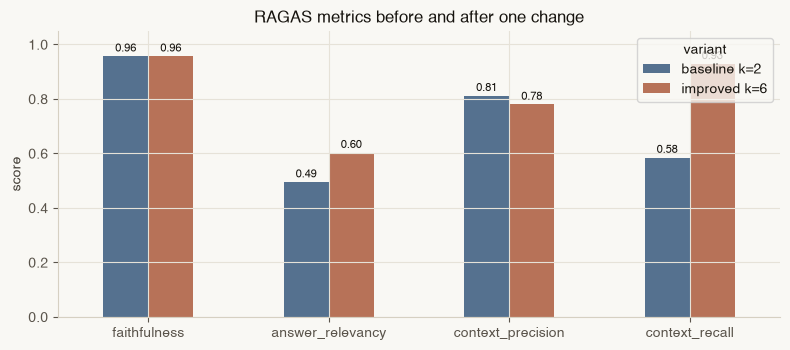

In [9]:
import matplotlib.pyplot as plt
from helpers.brand import matplotlib_style

plt.rcParams.update(matplotlib_style())
ax = compare[[c for c in compare.columns if c != "delta"]].plot.bar(figsize=(8, 3.6), rot=0)
ax.set_ylim(0, 1.05); ax.set_ylabel("score"); ax.set_xlabel(""); ax.set_title("RAGAS metrics before and after one change")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout(); plt.show()

You should see a ✅ line with two rows, a table with a delta column, a bar chart, and a faithfulness line with its interval. At six questions that interval usually spans zero: the delta is not yet a measured difference. Stop here if every delta is exactly zero: both runs used the same retriever, so check `k` on `improved_retriever`.


### ❓ Question
Which metric is lowest after the change, and does that point at retrieval or at the model? Which delta does the interval let you claim, and what would you change next?

Answer:


## Your turn

Change a different thing: the chunk size. Rebuild the store at 400 characters, keep `k` at 6, score again, and add the row to the saved scores. Then say which change moved which metric, and which `k` and chunk size you would ship for these questions.

In [10]:
MY_CHUNK_SIZE = 400
small_store, small_chunks = build_store(MY_CHUNK_SIZE, 60, f"corpus_{MY_CHUNK_SIZE}")
my_rows = run_rag(small_store.as_retriever(search_kwargs={"k": 6}), TESTSET)
my_scores = score(my_rows, f"chunks {MY_CHUNK_SIZE}")
SCORES.append({"variant": f"chunks {MY_CHUNK_SIZE} k=6", **my_scores, "k": 6, "chunk_size": MY_CHUNK_SIZE})
ws.save("ragas_scores", SCORES)
ui.table(pd.DataFrame(SCORES).set_index("variant")[COLUMNS], title="three variants")

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

✅ wrote ragas_scores → workspace/retrieval/ragas_scores.csv (3 rows)


                                     three variants                                      
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ variant        ┃ faithfulness ┃ answer_relevancy ┃ context_precision ┃ context_recall ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ baseline k=2   │        0.957 │            0.495 │             0.812 │          0.585 │
│ improved k=6   │        0.957 │            0.603 │             0.780 │          0.929 │
│ chunks 400 k=6 │        0.987 │            0.691 │             0.712 │          0.777 │
└────────────────┴──────────────┴──────────────────┴───────────────────┴────────────────┘

# Grow


## From prototype to production

| What we built | Production equivalent |
|---|---|
| Eight questions generated from a few pages | Hundreds of questions across the corpus, filtered for quality |
| A few personas and query styles | Personas and styles tuned to real user traffic |
| Four metrics run once in a notebook | Metric suites tracked over time per release |
| `k` and chunk size changed by hand | Sweeps over chunking, retrieval, and rerankers |
| A datasheet printed in a cell | A datasheet committed beside the test set and reviewed before it gates anything |
| A before and after chart | An eval gate in CI that blocks a regression |
| One judge model | Several judges with human spot checks and bias controls |

## Responsible controls

- The synthetic test set reviewed by a person before it gates anything.
- Metric thresholds agreed before the change, not after.
- Generator model and version recorded with every test set.


## Grow further

- Inspect the knowledge graph the generator built with `generator.knowledge_graph` and explain why it asked one multi-hop question.
- Pass a `query_distribution` to weight multi-hop questions higher and see which metric drops first.
- Wrap the evaluation in a script that exits non-zero when context recall falls below a threshold, and run it before any retrieval change merges.